In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
import skimage.color as skc
import skimage.io as skio
import skimage.transform as skt

from itertools import combinations
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm


from utils.utils import (read_config, read_samples_df, 
                         class_to_rgb,
                         class_to_vegetal, class_to_artificial,
                         artificial_to_rgb, vegetal_to_rgb,
                         fast_down_sample, fast_up_sample
                         )
 

In [3]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
config = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir)

Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs'),
 'pixels_df': PosixPath('/workspaces/flairimages/data/test/testpixels.pkl')}


In [4]:

# read the sample table in csv format
df = read_samples_df(conf=config)
# set to  indexing by number for simplicity (and memory ?)
df.reset_index(drop=False, inplace=True)
df.head()



,name,image,mask,domain,zone,patch_centroid_x,patch_centroid_y,patch_centroid_z,date,time,camera
0,IMG_062613,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705075.2,6358476.8,701.719971,2019-08-14,10h56,UCE-M3-f100
1,IMG_062614,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705177.6,6358476.8,711.409973,2019-08-14,10h56,UCE-M3-f100
2,IMG_062615,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705280.0,6358476.8,723.130005,2019-08-14,10h56,UCE-M3-f100
3,IMG_062616,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705382.4,6358476.8,735.22998,2019-08-14,10h56,UCE-M3-f100
4,IMG_062617,/workspaces/flairimages/data/test/flair_1_aeri...,/workspaces/flairimages/data/test/flair_1_labe...,D012_2019,Z10_UU,705495.15,6358481.22,737.109985,2019-08-14,10h30,UCE-M3-f100


config['image_shape'] is [512, 512, 5], 
found (512, 512, 5) in actual image, 
dtype:uint8
min=(36, 36, 22, 36, 0),
max=(230, 215, 218, 159, 42)
Actual mask of shape (512, 512) , dtype:uint8


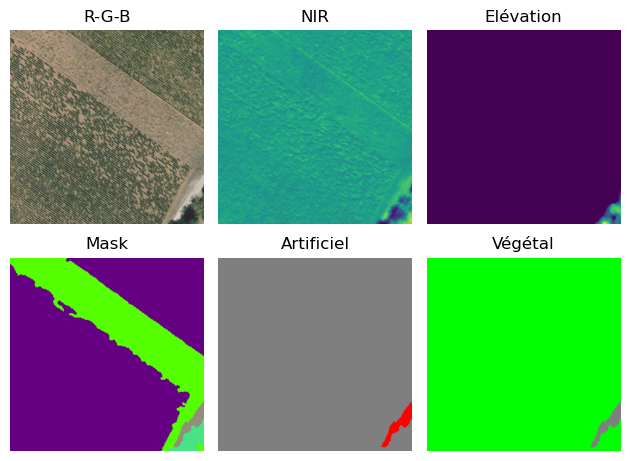

In [9]:
# set seed for df.sample() to get reproducible results
seed = 10041959
np.random.seed(seed)


# select a random record from df
# and extract the name, image and mask file paths.
name, image_file, mask_file = df.sample().iloc[0][['name','image', 'mask']].values
# print(name)
# print(image_file)
# print(mask_file)
img = skio.imread(image_file, plugin='tifffile')
msk = skio.imread(mask_file)
#    
print(f"config['image_shape'] is {config['image_shape']}, \nfound {img.shape} in actual image, \ndtype:{img.dtype}")
print(f"min={tuple(img.min(axis=(0,1)))},\nmax={tuple(img.max(axis=(0,1)))}")
print(f"Actual mask of shape {msk.shape} , dtype:{img.dtype}")

#
plt.subplot(2,3,1)
plt.imshow(img[:,:,:3])
plt.title("R-G-B")
plt.axis("off")
#
plt.subplot(2,3,2)
plt.imshow(img[:,:,3:4])
plt.title("NIR")
plt.axis("off")
#
plt.subplot(2,3,3)
plt.imshow(img[:,:,4])
plt.title("Elévation")
plt.axis("off")
#
msk_rgb = class_to_rgb(arr=msk, config=config)
plt.subplot(2,3,4)
plt.imshow(msk_rgb)
plt.title("Mask")
plt.axis("off")
#
msk_artificial = class_to_artificial(arr=msk, conf=config)
msk_rgb = artificial_to_rgb(arr=msk_artificial, conf=config)
plt.subplot(2,3,5)
plt.imshow(msk_rgb)
plt.title("Artificiel")
plt.axis("off")
#
msk_vegetal = class_to_vegetal(arr=msk, conf=config)
msk_rgb = vegetal_to_rgb(arr=msk_vegetal, conf=config)
plt.subplot(2,3,6)
plt.imshow(msk_rgb)
plt.title("Végétal")
plt.axis("off")
#
plt.tight_layout()
plt.show()

float64
float64
float64
float64
float64
float64


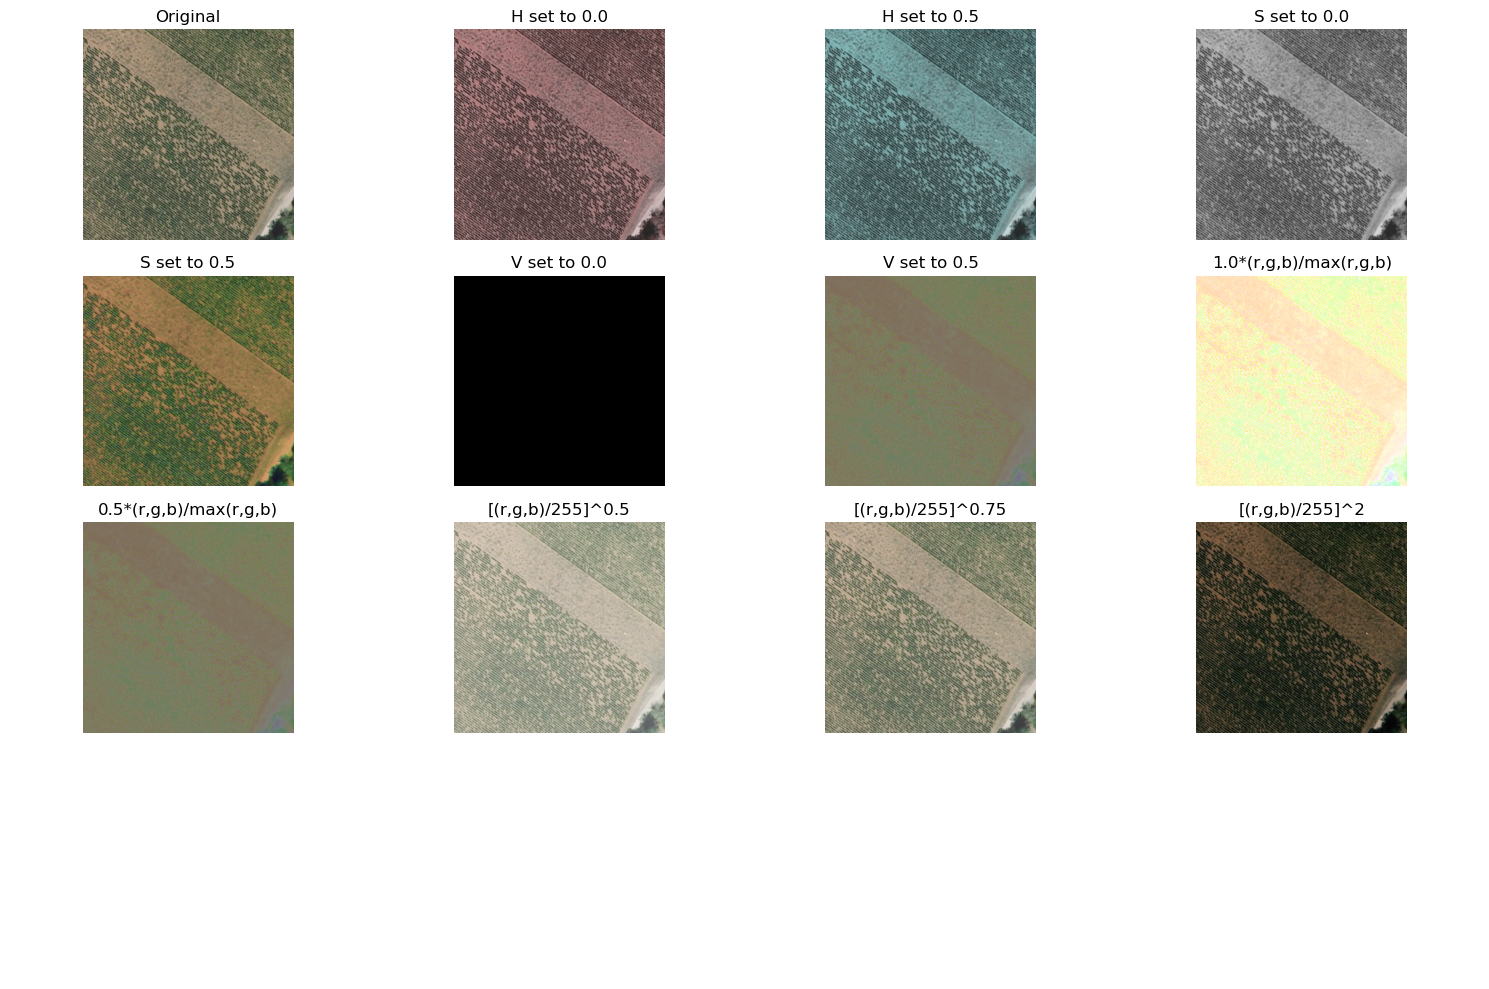

In [5]:
# test various transformations
fig, axes = plt.subplots(4,4, figsize=(15,10) )    
for ax in axes.flatten():
    ax.axis("off")
axes = iter(axes.flatten())
#
ax=next(axes)
ax.axis("off")
ax.imshow(img[:,:,:3])
ax.set_title("Original")
#
for channel in range(3):
    for v in [0.0,0.5]:
        ax=next(axes)
        ax.axis("off")
        test=skc.rgb2hsv(img[:,:,:3])
        print(test.dtype)
        test[:,:,channel] = v 
        ax.imshow(skc.hsv2rgb(test))#, cmap='hsv')
        ax.set_title(f"{'HSV'[channel]} set to {v}")
#
for f in [1.0,0.5]:
    ax=next(axes)
    ax.axis("off")
    test = img[:,:,:3]
    test=f*test/np.max(test, axis=(-1,), keepdims=True)
    ax.imshow(test)
    ax.set_title(f"{f:0.1f}*(r,g,b)/max(r,g,b)")
#
for alpha in [0.5, 0.75, 2]:
    ax=next(axes)
    ax.axis("off")
    test=(img[:,:,:3]/255)**alpha
    ax.imshow(test)
    ax.set_title(f"[(r,g,b)/255]^{alpha}")
plt.tight_layout()



In [11]:
# Here we make a sample of pixels in a dataset

n_pixel_samples = 100
# decide how many pixels we want per image in the dataset
n_images_dataset = df.shape[0]
# this is like draw a random image per desired pixel and sum by image 
pixels_per_image = np.random.multinomial(n=n_pixel_samples, pvals=np.ones(df.shape[0])/df.shape[0])
# prepare the dataframe to store the pixels
# image index + 5 bands + 1 mask value
pixel_df_columns = {#'index':df.index.values.dtype,
                    'image_loc':df.index.values.dtype,
                    'R':np.uint8, 
                    'G':np.uint8, 
                    'B':np.uint8, 
                    'NIR':np.uint8, 
                    'Elevation':np.uint8,
                    'Class':np.uint8,
                    'Artificial':np.uint8,
                    'Vegetal':np.uint8}
                

pixel_df = pd.DataFrame(data=np.zeros((n_pixel_samples,len(pixel_df_columns))),
                        columns=pixel_df_columns.keys(), 
                        index=range(n_pixel_samples))

pixel_df=pixel_df.astype(pixel_df_columns)
print(pixel_df.info())

sample_pixels =  np.zeros((n_pixel_samples, 5+1), dtype=np.uint8)
sample_pixel_image_loc = np.zeros((n_pixel_samples, 1), dtype=df.index.values.dtype)


# draw the pixels in each image

pixel_block_start = 0
for i_image, n_pixels in tqdm(enumerate(pixels_per_image)):
    # skip if no pixels to draw
    if n_pixels == 0:
        continue
    
    # get the image and mask
    image_file, mask_file = df.iloc[i_image][['image', 'mask']].values
    img = skio.imread(image_file, plugin='tifffile')
    msk = skio.imread(mask_file)

    
    # draw the pixels
    # get the pixels
    pixels_in_image = np.random.randint(low=0, high=img.shape[0]*img.shape[1], size=n_pixels)
    # get the pixels values
    img_pixels = img.reshape(-1, img.shape[2])[pixels_in_image, :]
    #msk_pixels = msk.reshape(-1, msk.shape[2])[pixels_in_image, :]
    msk_pixels = msk.reshape(-1, 1)[pixels_in_image,:]
    
    # store the image number and the pixels values
    sample_pixel_image_loc[pixel_block_start:pixel_block_start+n_pixels] = i_image
    sample_pixels[pixel_block_start:pixel_block_start+n_pixels, :5] = img_pixels
    sample_pixels[pixel_block_start:pixel_block_start+n_pixels, 5:5+1] = msk_pixels
    pixel_block_start += n_pixels

# store the pixels in the dataframe
pixel_df['image_loc'] = sample_pixel_image_loc
pixel_df[['R', 'G', 'B', 'NIR', 'Elevation','Class']] = sample_pixels[:, :5+1]
# add the artificial and vegetal columns
pixel_df['Artificial'] = class_to_artificial(conf=config, arr=pixel_df['Class'])
pixel_df['Vegetal'] = class_to_vegetal(conf=config, arr=pixel_df['Class'])
    



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_loc   100 non-null    int64
 1   R           100 non-null    uint8
 2   G           100 non-null    uint8
 3   B           100 non-null    uint8
 4   NIR         100 non-null    uint8
 5   Elevation   100 non-null    uint8
 6   Class       100 non-null    uint8
 7   Artificial  100 non-null    uint8
 8   Vegetal     100 non-null    uint8
dtypes: int64(1), uint8(8)
memory usage: 1.7 KB
None


0it [00:00, ?it/s]

In [12]:
pixel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_loc   100 non-null    int64
 1   R           100 non-null    uint8
 2   G           100 non-null    uint8
 3   B           100 non-null    uint8
 4   NIR         100 non-null    uint8
 5   Elevation   100 non-null    uint8
 6   Class       100 non-null    uint8
 7   Artificial  100 non-null    uint8
 8   Vegetal     100 non-null    uint8
dtypes: int64(1), uint8(8)
memory usage: 1.7 KB


In [10]:
# verify plausibility of the results
pixel_df.groupby(by=['Class']).mean()


,image_loc,R,G,B,NIR,Elevation,Artificial,Vegetal
Class,,,,,,,,
1,5504.875000,126.000000,134.500000,134.750000,71.500000,46.875000,1.0,0.0
2,8305.666667,193.333333,185.000000,171.833333,140.000000,13.833333,1.0,0.0
3,7977.772727,127.363636,131.818182,129.636364,80.136364,6.863636,1.0,0.0
4,8431.333333,169.333333,159.000000,139.333333,97.666667,0.000000,0.0,0.0
5,10853.750000,67.250000,79.500000,79.000000,47.750000,11.250000,0.0,0.0
6,9327.000000,78.333333,94.666667,81.666667,90.333333,35.000000,0.0,1.0
7,7332.250000,67.500000,83.666667,67.916667,125.166667,44.500000,0.0,1.0
8,6146.555556,84.666667,94.666667,83.333333,115.222222,5.111111,0.0,1.0
9,9977.500000,105.000000,111.500000,90.000000,132.000000,4.500000,0.0,1.0


In [11]:
pixel_df.groupby(by=['Vegetal']).mean()


,image_loc,R,G,B,NIR,Elevation,Class,Artificial
Vegetal,,,,,,,,
0,7750.276596,138.680851,140.361702,134.851064,88.021277,13.93617,3.531915,0.765957
1,7132.056604,99.301887,108.811321,93.509434,124.849057,14.00000,8.773585,0.000000


In [12]:
pixel_df.groupby(by=['Artificial']).mean()

,image_loc,R,G,B,NIR,Elevation,Class,Vegetal
Artificial,,,,,,,,
0,7388.718750,106.421875,113.718750,98.953125,118.421875,12.312500,8.515625,0.828125
1,7482.888889,138.055556,141.277778,137.805556,88.194444,16.916667,2.388889,0.000000


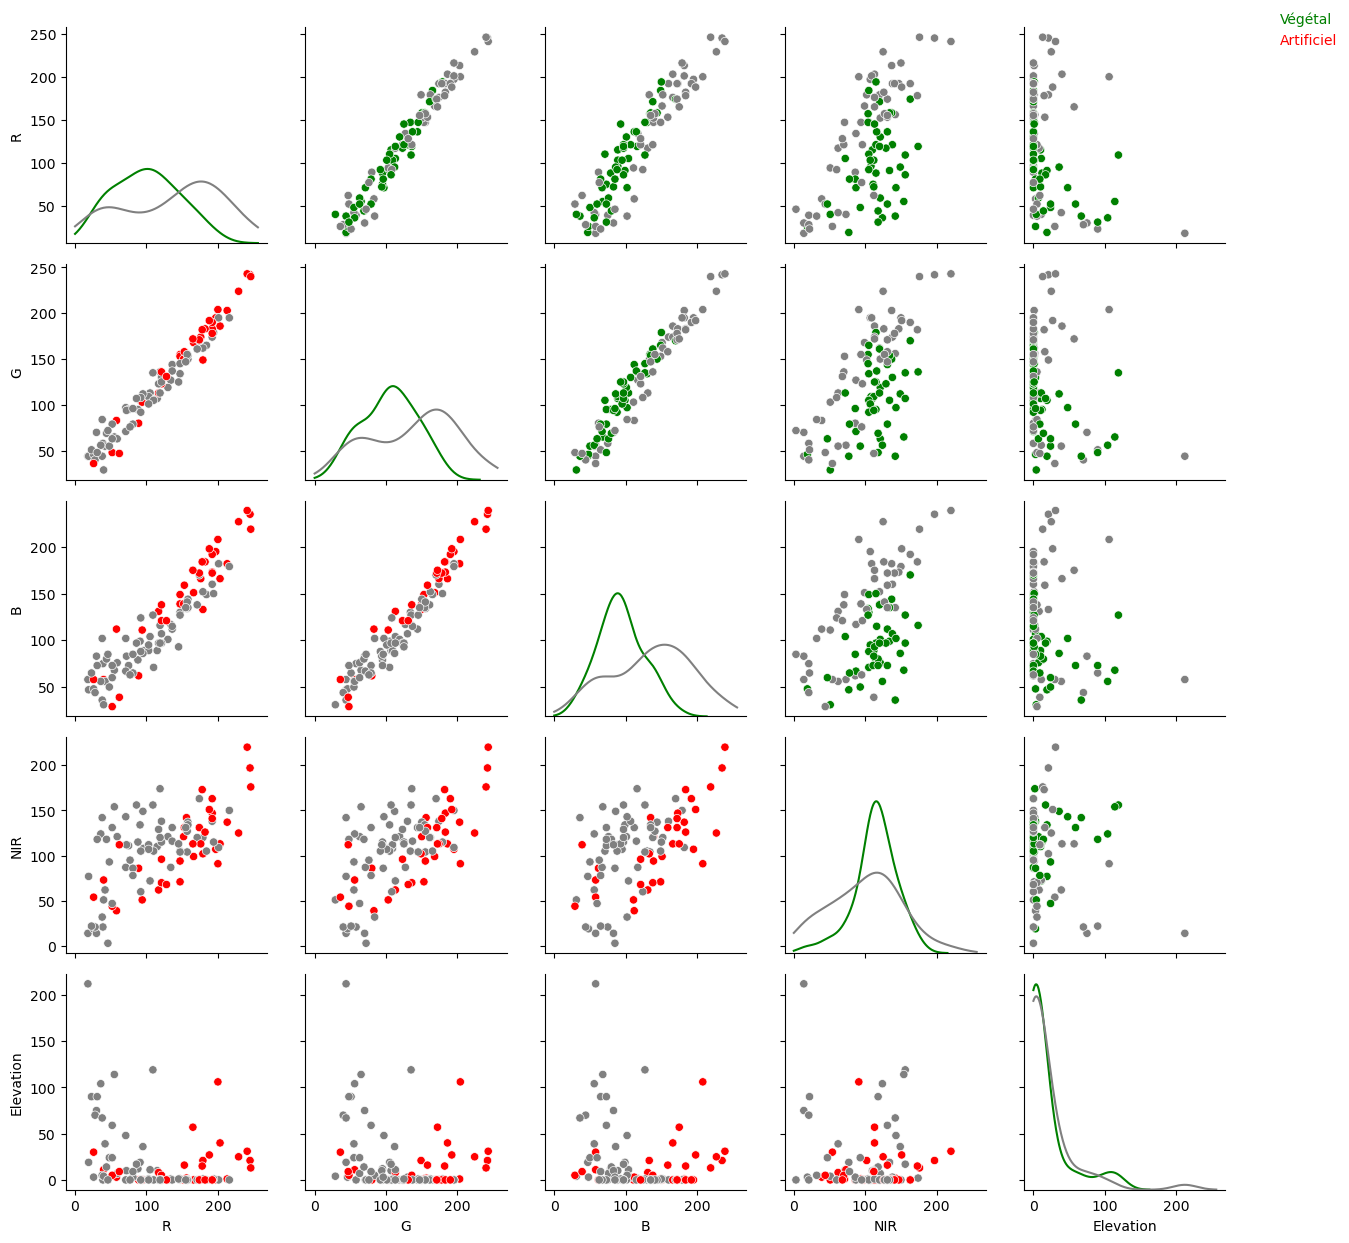

In [35]:
vars = ['R', 'G', 'B', 'NIR', 'Elevation']
vegetal_palette = sns.color_palette(["grey","green"])
artificial_palette = sns.color_palette(["grey","red"])
g=sns.PairGrid(data=pixel_df, vars=vars, hue='Vegetal', palette=vegetal_palette)

g.map_diag(sns.kdeplot, clip=[0,256])
#
g.map_upper(sns.scatterplot,hue = pixel_df.Vegetal, palette=vegetal_palette)
#
g.map_lower(sns.scatterplot,hue = pixel_df.Artificial, palette=artificial_palette) 
#
# add legend for upper plots hue
g.add_legend(label_order=['Végétal','Artificiel'], labelcolor=['green','red'], title='', loc='upper right')


 


In [21]:
sns.color_palette(["red","grey"])

[(1.0, 0.0, 0.0), (0.5019607843137255, 0.5019607843137255, 0.5019607843137255)]

In [14]:
# make logist regression of artificial~R+G+B+NIR+Elevation
def make_logistic_regression(X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[('scaler', StandardScaler()),
                               ('log_reg', LogisticRegression())])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    # create a sklearn pipeline
    return pipeline, score


all_X_vars = ['R', 'G', 'B']#, 'NIR', 'Elevation']
all_y_vars = ['Artificial', 'Vegetal']

# enumerate all the possible combinations of 3 variables
estimators = dict()


seed = 10041958
pixel_train_df, pixel_test_df = train_test_split(pixel_df[all_X_vars+all_y_vars], test_size=0.2, random_state=seed)
for y_var in all_y_vars:
    estimators[y_var] = dict()
    for i in range (1, len(all_X_vars)+1):
        for X_vars in combinations(all_X_vars, i):
            #print(f"X_vars:{X_vars}")
            logreg, score = make_logistic_regression(X_train = pixel_train_df[list(X_vars)].values,
                                                     X_test  = pixel_test_df[list(X_vars)].values,
                                                     y_train = pixel_train_df[y_var].values,
                                                     y_test  = pixel_test_df[y_var].values)
            reg_equation = f"{y_var}~{'+'.join(X_vars)}"
            print(reg_equation+f"\t\t\t\t f score is {score}")
            estimators[reg_equation] = logreg
#print(dict(zip(vars,logreg.coef_[0 ])))
#print(f"f score is {score}")


Artificial~R				 f score is 0.6
Artificial~G				 f score is 0.6
Artificial~B				 f score is 0.8
Artificial~R+G				 f score is 0.6
Artificial~R+B				 f score is 0.8
Artificial~G+B				 f score is 0.8
Artificial~R+G+B				 f score is 0.8
Vegetal~R				 f score is 0.8
Vegetal~G				 f score is 0.8
Vegetal~B				 f score is 0.75
Vegetal~R+G				 f score is 0.85
Vegetal~R+B				 f score is 0.75
Vegetal~G+B				 f score is 0.75
Vegetal~R+G+B				 f score is 0.75


memo: in 'IMG_073414' prediction seems better than human mask

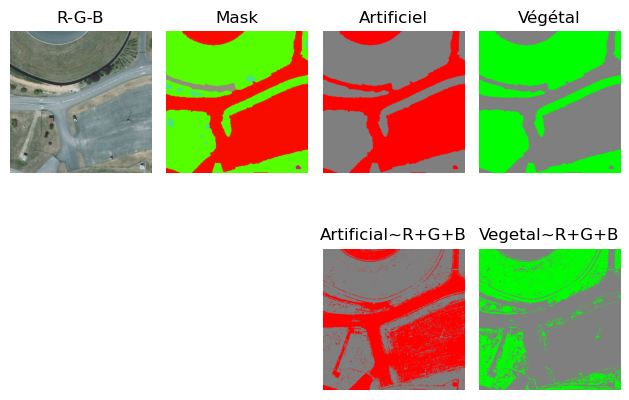

In [18]:
# set seed for df.sample() to get reproducible results
if False:
    seed = 10041958
    np.random.seed(seed)


# select a random record from df
# and extract the name, image and mask file paths.
name, image_file, mask_file = df.sample().iloc[0][['name','image', 'mask']].values
# print(name)
# print(image_file)
# print(mask_file)
with rasterio.open(image_file) as src:
    img = src.read()
    img = np.moveaxis(img, 0, -1)
with rasterio.open(mask_file) as src:
    msk = src.read()
    msk = np.moveaxis(msk, 0, -1)
#    
plt.subplot(2,4,1)
plt.imshow(img[:,:,:3])
plt.title("R-G-B")
plt.axis("off")
#
msk_palette = class_to_rgb(arr=msk[:,:,0], config=config)
plt.subplot(2,4,2)
plt.imshow(msk_palette)
plt.title("Mask")
plt.axis("off")
#
msk_artificiel = artificial_to_rgb(class_to_artificial(arr=msk[:,:,0], conf=config),
                                     conf=config)
plt.subplot(2,4,3)
plt.imshow(msk_artificiel)
plt.title("Artificiel")
plt.axis("off")
#
msk_vegetal = vegetal_to_rgb(class_to_vegetal(arr=msk[:,:,0], conf=config),
                                conf=config)
plt.subplot(2,4,4)
plt.imshow(msk_vegetal)
plt.title("Végétal")
plt.axis("off")
#

reg_equation = 'Artificial~R+G+B'
msk_pred = estimators[reg_equation].predict(img[:,:,:3].reshape(-1,3)).reshape(img.shape[:2])
rgb_pred = artificial_to_rgb(conf=config, arr=msk_pred)
plt.subplot(2,4,7)
plt.imshow(rgb_pred)
plt.title(reg_equation)
plt.axis("off")
#
reg_equation = 'Vegetal~R+G+B'
msk_pred = estimators[reg_equation].predict(img[:,:,:3].reshape(-1,3)).reshape(img.shape[:2])
rgb_pred = vegetal_to_rgb(conf=config, arr=msk_pred)
plt.subplot(2,4,8)
plt.imshow(rgb_pred)
plt.title(reg_equation)
plt.axis("off")
#
plt.tight_layout()
plt.show()
